## Objective
In this lab, you will analyze a customer dataset to identify key factors influencing customer churn, create visualizations to explore the data, and build a predictive model using machine learning. The goal is to extract actionable insights and present your findings in a comprehensive report.
## Scenario
You are a data analyst at a fast-growing subscription-based service company. The company is concerned about customer churn—customers canceling their subscriptions—and has tasked you with analyzing customer data. Your objectives are to identify key factors that influence churn and build a predictive model to identify customers at risk of leaving.
## Materials Provided
- A dataset (`customer_churn.csv`) preloaded into a pandas DataFrame named `df`.
- Python environment with essential libraries such as pandas, Scikit-Learn, and Matplotlib pre-installed.

## High-Level Tasks
1. **Load and Explore the Data**
2. **Data Cleaning and Preprocessing**
3. **Exploratory Data Analysis (EDA) and Visualization**
4. **Machine Learning Model Building and Evaluation**
5. **Presenting Findings in a Comprehensive Report**

## Lab Instructions
### 1. Load and Explore the Data
#### Step 1.1: Import the required Python library and load dataset.

In [1]:
import pandas as pd 
df = pd.read_csv("customer_churn.csv")

# Display the first 5 rows of the DataFrame
df.head()

,Unnamed: 0,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,0,128,Yes,1,2.7,1,265.1,110,89.0,9.87,10.0
1,1,0,107,Yes,1,3.7,1,161.6,123,82.0,9.78,13.7
2,2,0,137,Yes,0,0.0,0,243.4,114,52.0,6.06,12.2
3,3,0,84,No,0,0.0,2,299.4,71,57.0,3.10,6.6
4,4,0,75,No,0,0.0,3,166.7,113,41.0,7.42,10.1


#### Step 1.2: Examine Column Names and Data Types
Inspect the column names and data types using `df.info()`.

In [2]:
# Display column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       3333 non-null   int64  
 1   Churn            3333 non-null   int64  
 2   AccountWeeks     3333 non-null   int64  
 3   ContractRenewal  3333 non-null   str    
 4   DataPlan         3333 non-null   int64  
 5   DataUsage        3333 non-null   float64
 6   CustServCalls    3333 non-null   int64  
 7   DayMins          3333 non-null   float64
 8   DayCalls         3333 non-null   int64  
 9   MonthlyCharge    3333 non-null   float64
 10  OverageFee       3333 non-null   float64
 11  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6), str(1)
memory usage: 322.0 KB


#### Step 1.3: Get Summary Statistics
Get summary statistics of numerical columns using `df.describe()`.

In [3]:
# Get summary statistics of numerical columns
df.describe()

,Unnamed: 0,Churn,AccountWeeks,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.00000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,1666.00000,0.144914,101.064806,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,962.29855,0.352067,39.822106,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,833.00000,0.000000,74.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,1666.00000,0.000000,101.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,2499.00000,0.000000,127.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,3332.00000,1.000000,243.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


#### Step 1.4: Remove CSV Index Column
The index from the CSV turned into a column and should be dropped. Use `df.drop` to get rid of the `Unnamed: 0` column. Then use `df.describe()` again to confirm the column is removed.

In [4]:
# Drop the "Unnamed: 0" column
### YOUR CODE HERE ###
df = df.drop(columns="Unnamed: 0")
# Use df.describe() to confirm the column was removed (code provided)
df.describe()

# Expected shape of DataFrame is (3333,11) after dropping column. 
# Ensure the results are stored in the df variable
print(f"Shape: {df.shape}. Expected is (3333, 11)")

Shape: (3333, 11). Expected is (3333, 11)


#### Check Your Results:

In [5]:
# Checking DataFrame (df) shape
print(f"Shape: {df.shape}.")

Shape: (3333, 11).


#### Step 1.5: Identify Potential Features and Target Variable, and Encode ContractRenewal
Select all features from the dataset, except churn (e.g., `"AccountWeeks"`, `"DataPlan"`, `"Data Usage"`, etc) and set the target variable (`'churn'`).

The `ContractRenewal` column currently has text values ("Yes" or "No"). pd.get_dummies() converts these text values into numerical 1s and 0s. It creates new columns (`'ContractRenewal_Yes'`, `'ContractRenewal_No'`). A 'Yes' becomes a 1 in the 'Yes' column and 0 in the 'No' column, and vice versa. This allows us to use this information effectively in our machine learning models and in charts.

In [6]:
# Select all features and set target variable
### YOUR CODE HERE ###
features = df.iloc[:, 1:]
target_variable = df["Churn"]

features = pd.get_dummies(features,columns=['ContractRenewal'],dtype=int)

# Expected shape of features DataFrame is (3333,11) after one-hot encoding. 
print(f"features shape: {features.shape}. Expected is (3333, 11)")
# Expected shape of target_variable DataFrame is (3333,).
print(f"target_variable shape: {target_variable.shape}. Expected is (3333,)")
features.head()

features shape: (3333, 11). Expected is (3333, 11)
target_variable shape: (3333,). Expected is (3333,)


,AccountWeeks,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,ContractRenewal_No,ContractRenewal_Yes
0,128,1,2.7,1,265.1,110,89.0,9.87,10.0,0,1
1,107,1,3.7,1,161.6,123,82.0,9.78,13.7,0,1
2,137,0,0.0,0,243.4,114,52.0,6.06,12.2,0,1
3,84,0,0.0,2,299.4,71,57.0,3.10,6.6,1,0
4,75,0,0.0,3,166.7,113,41.0,7.42,10.1,1,0


### 2. Data Cleaning and Preprocessing (5 minutes)
#### Step 2.1: Split the Data
Split the data into training and testing sets (70% train, 30% test) using `train_test_split` from Scikit-Learn. 

Make sure to set the `random_state` parameter to 42 to ensure reproducibility and obtain the same results as the expected solution.

In [7]:
from sklearn.model_selection import train_test_split
# Assume "x" is features and "y" is target_variables
x = features 
y = target_variable

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(x_train.shape) # Expected (2333,11)
print(x_test.shape) # Expected (1000,11)
print(y_train.shape) # Expected (2333,)
print(y_test.shape) # Expected (1000,)

(2333, 11)
(1000, 11)
(2333,)
(1000,)


### 3. Exploratory Data Analysis (EDA) and Visualization
#### Step 3.1: Summary Statistics for Relevant Features
Calculate and print summary statistics for relevant features (average tenure for churned vs. non-churned customers).

In [8]:
# Summary statistics for churned vs. non-churned customers
churned = df[df["Churn"]==1]
non_churned = df[df["Churn"]==0]

# Print average tenure
### YOUR CODE HERE ###
avg_tenure_churned = churned["AccountWeeks"].mean()
avg_tenure_non_churned = non_churned["AccountWeeks"].mean()
print(avg_tenure_churned)
print(avg_tenure_non_churned)

102.66459627329192
100.79368421052632


#### Step 3.2: Create Visualizations
Create visualizations (bar chart, histogram, and box plot) to explore the relationships between features and the target variable (`'churn'`).

                 Churn  Non_churn
ContractRenewal                  
No                 137        186
Yes                346       2664


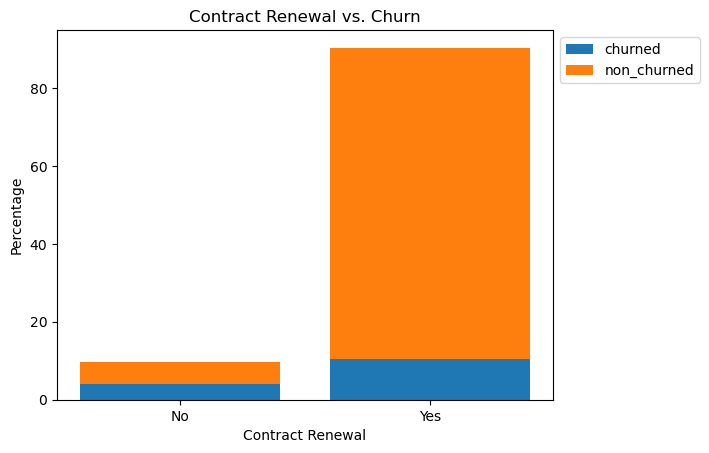

In [9]:
import matplotlib.pyplot as plt

# Bar chart for contract renewal vs churn
churn_counts = (df
                .assign(Non_churn=df["Churn"].transform(lambda x: x+1 if x==0 else x-1))
                .groupby("ContractRenewal")
                .agg({"Churn":"sum", "Non_churn":"sum"})
               )
print(churn_counts)

plt.bar(x=churn_counts.index, 
        height=churn_counts.loc[:,"Churn"] / df.shape[0]*100, 
        label="churned")
plt.bar(x=churn_counts.index, 
         height=churn_counts.loc[:,"Non_churn"] / df.shape[0]*100, 
         bottom=churn_counts.loc[:, "Churn"] / df.shape[0]*100,
         label="non_churned")
plt.title('Contract Renewal vs. Churn')
plt.xlabel('Contract Renewal')
plt.ylabel('Percentage')
plt.legend(bbox_to_anchor=(1,1))
plt.show()

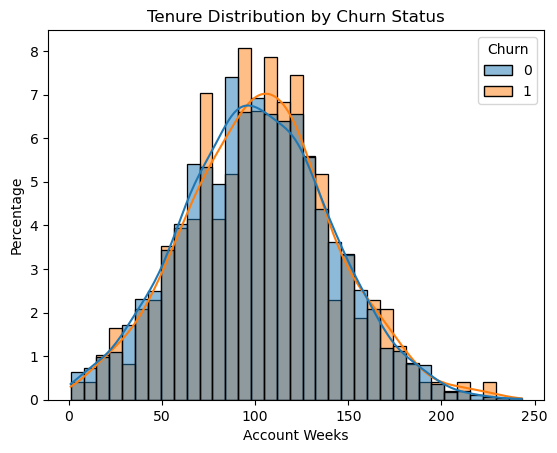

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for tenure distribution
# plt.hist([churned["AccountWeeks"], non_churned["AccountWeeks"]],
#          bins=20,
#          rwidth=0.5,
#          label=["churned", "non_churned"], 
#          density=True)

sns.histplot(x="AccountWeeks",
             data=df,
             hue="Churn",
             legend="full",
#              palette="husl",
             multiple="layer",
             stat="percent",
             kde=True,
             common_norm=False
            )

plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Account Weeks')
plt.ylabel('Percentage')
# plt.legend()
plt.show()

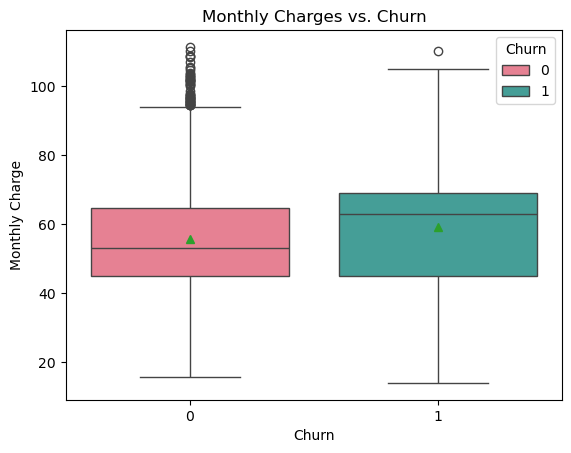

In [11]:
import matplotlib.pyplot as plt

# Box plot for monthly charges
# plt.boxplot([churned["MonthlyCharge"], non_churned["MonthlyCharge"]],
#             patch_artist=True,
#             boxprops={"color":"b", "facecolor":"b"},
#             showmeans=True)

sns.boxplot(x="Churn",
            y="MonthlyCharge",
            data=df,
            hue="Churn",
            palette="husl",
            showmeans=True)

plt.title('Monthly Charges vs. Churn')
plt.xlabel('Churn')
# plt.xticks(ticks=[1,2], labels=["1", "0"])
plt.ylabel('Monthly Charge')
plt.show()

#### Step 3.3: Interpret Visualizations
Interpret the visualizations and identify key insights about factors influencing churn.  Enter your observations in the cell below. These will not be graded, but this may be useful if you want to add this to your portfolio.

Enter your observations about the visualizations here:

- Observation 1: 
    - Churned customer count is NEARLY HALF (42% - This is nearly 30% of all churned customers) among the customers who did NOT renewed their contracts, given that contract non_renewal rate among all customers is below 10%.
    - The percentage of non_churned customers is nearly 90% among the customers who did renewed their contracts.
    - The churn rate among all customers is below 15%; contract non_renewal is closely linked with churn.
- Observation 2: Tenure histograms (prercent) of both churned and non_churned customers did NOT yield meaningful insights whether there could be a pattern difference of tenure between these categories.
- Observation 3: The monthly charge figures of non_churned customers seem to be less than that of the churned. This is expected as one might expect that the price should be a fundamental reason in churn.

### 4. Machine Learning Model Building and Evaluation (20 minutes)
#### Step 4.1: Choose a Classification Algorithm and Train the Model
Import a suitable classification algorithm (`LogisticRegression` in this case) and create an instance of it (provided). 

Setting `max_iter = 1000` in our Logistic Regression model means we're giving it a limit of 1000 attempts to learn the optimal patterns in the data, which is often a good initial value to allow for convergence without excessive training time, though the ideal number can vary depending on the specific dataset.

In [12]:
from sklearn.linear_model import LogisticRegression

# Create an instance of the Logistic Regression model (provided)
model = LogisticRegression(max_iter = 1000, random_state=42)

# Train the model
### YOUR CODE HERE ###
model.fit(x_test, y_test)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Step 4.2: Make Predictions
Use the trained model to make predictions on the testing data.

In [13]:
# Make predictions on the test set
y_pred = model.predict(x_test)

#### Step 4.3: Evaluate the Model
Evaluate the model's performance using appropriate metrics (`accuracy`, `precision`, `recall`, `f1`).

**Note:** For grading purposes, calculate and store each of these metrics in the following variables:
- `accuracy`
- `precision`
- `recall`
- `f1`

Accuracy: 0.867
Precision: 0.609
Recall: 0.196
F1 Score: 0.296


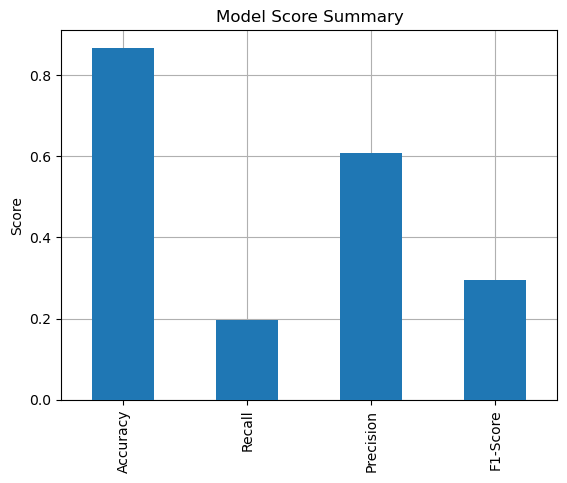

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate the model
# Round all values to 3 decimal places

accuracy = round(accuracy_score(y_test, y_pred),3)
precision = round(precision_score(y_test, y_pred),3)
recall = round(recall_score(y_test, y_pred),3)
f1 = round(f1_score(y_test, y_pred),3)

print(f"Accuracy: {accuracy}") # Expected: approximately 0.867
print(f"Precision: {precision}") # Expected: approximately 0.604
print(f"Recall: {recall}") # Expected: approximately 0.203
print(f"F1 Score: {f1}") # Expected: approximately 0.304

data = {
    "Accuracy": accuracy, 
    "Recall": recall, 
    "Precision": precision, 
    "F1-Score": f1
}
s_score = pd.Series(data)
s_score.plot.bar(grid=True, zorder=3)
plt.ylabel("Score")
plt.title("Model Score Summary");

#### Check Your Results:

### 5. Presenting Findings in a Comprehensive Report
#### Step 5.1: Compile the Results
Compile your analysis, visualizations, and model evaluation results into a comprehensive report. Fill them in as directed below. This will not be graded, but may be useful if you want to add this to your portfolio.
- `Introduction:` Write a sentence or two describing the purpose of this analysis.
- `Data Exploration:` Write a sentence or two highlighting the key factors in customer churn.
- `Model Building and Evaluation:` Write a sentence or two describing how your model was trained, and the accuracy, precision, and recall rates.
- `Key Insights:` Add two or three bullet points summarizing your findings.
- `Recommendations:` Add two or three bullet points with the recommendations you would make based on this analysis.

# Customer Churn Analysis Report

## Introduction
- This analysis is conducted to develop a basic machine learning model that would predict customer_churn (classification). The data consists of following columns: 'Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage', 'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee', 'RoamMins'.

## Data Exploration
- Data exploration herein is only comprised of the possible relationship between 'Churn' and 'AccountWeeks' / 'ContractRenewal' / 'MonthlyCharge'. Through histogram, bar and boxplot graphs respectively; significant relationship is discovered between 'Churn' and 'ContractRenewal' as well as a slight relationship between 'Churn' and 'MonthlyCharge'. However no  meaningful insight is grabbed from the histogram between 'Churn' and 'AccountWeeks'.

## Model Building and Evaluation
- Data is splitted into training and testing sections with a 0.3 test size.
- Logistic Regression model is employed from the scikit-learn library with maximum iteration of 1000.
- Model is trained.
- Model is put into work to predict 'Churn' on the test-alloted section of data.
- Actual and predicted 'Churn' values are compared against each other with classification metrics such as accuracy, precision, recall, f1.

## Key Insights
- IAW the metrics, model proved to have a medium precision score; but considerably insufficient recall and f1 scores, which in turn means, the model can predict 'Churn' customers with moderate precision, tagging many non_churned as 'Churn' as well. Making things worse, most of the 'Churn' customers are settled without tagged as so.

## Recommendations
- The model failed.
- Model change or hyperparametrization is required.